In [ ]:
!pip install transformers huggingface_hub torch

In [ ]:
!pip install langchain langchain_community chromadb langgraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 992.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4

In [ ]:
!pip install --upgrade "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 34.2 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


**Pipeline Inputs & Outputs**

The clinical assistant pipeline operates as a contextualized, retrieval-augmented decision system integrating structured patient data, internal hospital protocols, and automated safety guardrails.

* **Inputs:**
* **User Query:** Clinical question or instruction from a medical professional entered via chat or voice prompt.
* **Session Metadata (Optional):** Active `patient_id` passed directly from the Electronic Health Record (EHR) interface.
* **Internal Knowledge Base:** Hospital protocols, clinical guidelines, and standard operating procedures.


* **Outputs:**
* **Contextualized Recommendation:** Medical guidance framed around patient history and institutional protocols.
* **Source Citations (Explainability):** Direct protocol and reference links used to construct the answer.
* **System Alerts:** Warnings regarding pending diagnostic tests or critical data.
* **Structured Audit Payload:** Immutable log entry containing queries, retrieved context, generated text, safety flags, and user approvals.



---

**LangGraph Workflow Architecture**

The system uses LangGraph to coordinate entity extraction, EHR database retrieval, protocol search, LLM generation, guardrail evaluation, and physician validation gates.

**Graph State Schema**

* `user_query`: Raw prompt provided by the physician.
* `patient_id`: String identifier parsed from the query or incoming session metadata.
* `missing_patient_id`: Boolean flag set if no patient context can be established.
* `patient_context`: EHR record containing medical history and pending tests.
* `retrieved_docs`: Chunks and citations retrieved from internal protocol databases.
* `llm_output`: Response generated by the fine-tuned LLM.
* `requires_human_approval`: Flag set when safety checks detect high-risk suggestions.
* `audit_payload`: Log metadata tracking full execution lifecycle.

**Nodes**

* **`parse_and_validate_input`:** Extracts `patient_id` from incoming metadata or parses it from `user_query` using named entity recognition/regex.
* **`request_patient_id`:** Formats a response prompting the user to specify a patient when no `patient_id` is found.
* **`fetch_ehr_context`:** Queries EHR databases using `patient_id` to retrieve history and check pending tests.
* **`retrieve_protocols`:** Vector search node fetching internal medical guidelines to guarantee explainability.
* **`generate_llm_response`:** Synthesizes context, protocols, and query using the fine-tuned LLM.
* **`guardrail_evaluator`:** Inspects output to block direct unvalidated prescriptions or unauthorized procedures.
* **`human_validation_gate`:** Holds execution for physician sign-off on flagged high-risk actions.
* **`audit_logger`:** Writes execution traces and validation states to audit storage.

**Graph Edges & Execution Flow**

* **`START`** $\rightarrow$ **`parse_and_validate_input`**
* **Conditional Edge (`parse_and_validate_input`):**
* If `missing_patient_id == True` $\rightarrow$ **`request_patient_id`** $\rightarrow$ **`END`**
* If `missing_patient_id == False` $\rightarrow$ **`fetch_ehr_context`** $\rightarrow$ **`retrieve_protocols`** $\rightarrow$ **`generate_llm_response`** $\rightarrow$ **`guardrail_evaluator`**


* **Conditional Edge (`guardrail_evaluator`):**
* If `requires_human_approval == True` $\rightarrow$ **`human_validation_gate`** $\rightarrow$ **`audit_logger`** $\rightarrow$ **`END`**
* If `requires_human_approval == False` $\rightarrow$ **`audit_logger`** $\rightarrow$ **`END`**

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from huggingface_hub import login

In [ ]:
login()

In [ ]:
import torch

# Load model and tokenizer to GPU if available
device_map = 'auto'
if torch.cuda.is_available():
    device_map = 'cuda'
    print("Model will load to GPU.")
else:
    print("GPU not available, model running on CPU.")

model_name = "Grupo-de-Estudos-GPRSW/meditron-7b-finetuned-MedQuAD"
tokenizer = AutoTokenizer.from_pretrained(model_name, device_map=device_map)
model = AutoModelForCausalLM.from_pretrained(model_name, device_map=device_map)

Model moved to GPU.


tokenizer_config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.62M [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/610 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

adapter_model.safetensors: reconstructing file:   0%|          |  0.00B / 16.8MB            

adapter_model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

In [ ]:
from typing import TypedDict, List, Dict, Any

class GraphState(TypedDict):
    """Represent a state for our graph."""
    patient_id: str
    missing_patient_id: bool
    user_query: str
    patient_context: Dict[str, Any]  # Structured record of patient data
    retrieved_docs: List[str]  # Document chunks and citations
    llm_output: str  # Draft response from LLM
    requires_human_approval: bool  # Flag for safety evaluation
    audit_payload: Dict[str, Any]  # Log metadata

## Mock Patient Database

This `mock_patient_db` is a list of dictionaries, where each dictionary represents a patient record. Each patient record includes:

*   `patient_id`: A unique identifier for the patient.
*   `medical_history`: A list of medical conditions the patient has.
*   `current_medications`: A list of medications the patient is currently taking.
*   `pending_tests`: A list of any tests that are pending for the patient.

In [ ]:
mock_patient_db = [
    {
        "patient_id": "P001",
        "medical_history": ["Type 2 Diabetes", "Hypertension"],
        "current_medications": ["Metformin", "Lisinopril"],
        "pending_tests": []
    },
    {
        "patient_id": "P002",
        "medical_history": ["Asthma", "Seasonal Allergies"],
        "current_medications": ["Albuterol inhaler"],
        "pending_tests": ["Pulmonary Function Test"]
    },
    {
        "patient_id": "P003",
        "medical_history": ["Coronary Artery Disease"],
        "current_medications": ["Aspirin", "Atorvastatin"],
        "pending_tests": ["Stress Test"]
    },
    {
        "patient_id": "P004",
        "medical_history": ["Migraines"],
        "current_medications": ["Sumatriptan"],
        "pending_tests": []
    },
    {
        "patient_id": "P005",
        "medical_history": ["Hypothyroidism"],
        "current_medications": ["Levothyroxine"],
        "pending_tests": ["TSH level check"]
    },
    {
        "patient_id": "P006",
        "medical_history": ["GERD"],
        "current_medications": ["Omeprazole"],
        "pending_tests": []
    },
    {
        "patient_id": "P007",
        "medical_history": ["Osteoarthritis"],
        "current_medications": ["Ibuprofen"],
        "pending_tests": ["Knee X-ray"]
    },
    {
        "patient_id": "P008",
        "medical_history": ["Anxiety Disorder"],
        "current_medications": ["Sertraline"],
        "pending_tests": []
    },
    {
        "patient_id": "P009",
        "medical_history": ["Chronic Kidney Disease (Stage 3)"],
        "current_medications": ["Furosemide"],
        "pending_tests": ["Kidney Function Panel"]
    },
    {
        "patient_id": "P010",
        "medical_history": ["Pneumonia (resolved)" ],
        "current_medications": [],
        "pending_tests": ["Follow-up Chest X-ray"]
    }
]

### Node: `parse_and_validate_input`

This node is responsible for initializing the workflow by attempting to identify the `patient_id` from the user's input.

**Functionality:**
1.  **Extracts `user_query`**: It retrieves the raw prompt provided by the physician.
2.  **Identifies `patient_id`**:
    *   If a `patient_id` is already present in the `state` (e.g., from session metadata), it uses that.
    *   Otherwise, it tries to extract a `patient_id` from the `user_query` using a regular expression (e.g., finding patterns like `P001`, `P123`).
3.  **Sets `missing_patient_id` flag**: A boolean flag is set to `True` if no `patient_id` could be found or extracted, indicating that the system cannot proceed without this critical piece of information.
4.  **Updates `audit_payload`**: Logs whether the input was parsed and if a patient ID was found.

In [ ]:
import re

def parse_and_validate_input(state: GraphState) -> GraphState:
    """Extracts patient_id from incoming metadata or parses it from user_query."""
    user_query = state.get("user_query", "")
    patient_id = state.get("patient_id")

    # Attempt to extract patient_id from user_query if not already present
    if not patient_id and user_query:
        # Regex to find patient IDs like P001, P123, etc.
        match = re.search(r"P\d{3}", user_query)
        if match:
            patient_id = match.group(0)
            print(f"Patient ID '{patient_id}' extracted from query.")

    missing_patient_id = patient_id is None

    print(f"--- Parsing and Validating Input ---")
    return {
        "patient_id": patient_id,
        "missing_patient_id": missing_patient_id,
        "audit_payload": {"input_parsed": True, "patient_id_found": not missing_patient_id}
    }

### Node: `request_patient_id`

This node is activated when the `parse_and_validate_input` node determines that no `patient_id` could be found or extracted from the user's query or session metadata.

**Functionality:**
1.  **Sets `llm_output`**: It generates a user-friendly message prompting the medical professional to provide the patient's identifier.
2.  **Sets `missing_patient_id`**: It maintains the `missing_patient_id` flag as `True` to reflect that the patient context is still unresolved.
3.  **Updates `audit_payload`**: Logs that a request for a patient ID has been issued.

In [ ]:
def request_patient_id(state: GraphState) -> GraphState:
    """Formats a response prompting the user to specify a patient when no patient_id is found."""
    print(f"--- Requesting Patient ID ---")
    return {
        "llm_output": "Please provide a patient identifier (e.g., P123) so I can retrieve their information.",
        "missing_patient_id": True,
        "audit_payload": {"patient_id_requested": True}
    }

### Node: `fetch_ehr_context`

This node simulates querying a structured Electronic Health Record (EHR) database to retrieve relevant patient information based on the `patient_id`.

**Functionality:**
1.  **Retrieves `patient_id`**: It takes the `patient_id` from the current graph state.
2.  **Searches Mock Database**: It iterates through the `mock_patient_db` to find a matching patient record.
3.  **Extracts Context**: If a patient is found, it extracts their `medical_history`, `current_medications`, and `pending_tests`.
4.  **Handles Missing Patient**: If the `patient_id` is not found in the mock database, it prints a warning.
5.  **Updates `patient_context`**: The retrieved patient information is stored in the `patient_context` field of the graph state.

In [ ]:
def fetch_ehr_context(state: GraphState) -> GraphState:
    """Queries structured patient databases to retrieve history and check pending tests."""
    patient_id = state["patient_id"]
    patient_context = {}
    for patient in mock_patient_db:
        if patient["patient_id"] == patient_id:
            patient_context = {
                "medical_history": patient["medical_history"],
                "current_medications": patient["current_medications"],
                "pending_tests": patient["pending_tests"]
            }
            break

    if not patient_context:
        print(f"Warning: Patient {patient_id} not found in mock database.")

    print(f"--- Fetched EHR Context for Patient {patient_id} ---")
    return {"patient_context": patient_context}

### Mock Clinical Protocols and ChromaDB Vector Store

This section defines a set of `mock_protocols` representing various clinical guidelines. These protocols are then embedded using the pre-loaded language model and stored in an in-memory ChromaDB vector store (`protocols_collection`) for efficient semantic search by the `retrieve_protocols` node.

In [ ]:
mock_protocols = [
    {"protocol_id": "PR001", "title": "Diabetes Management Guidelines", "content": "Protocol for managing Type 2 Diabetes, including medication adjustments, diet, and exercise recommendations. Focus on Metformin dosage and blood sugar monitoring."},
    {"protocol_id": "PR002", "title": "Hypertension Treatment Pathway", "content": "Guidelines for treating essential hypertension. Includes use of ACE inhibitors like Lisinopril, lifestyle modifications, and regular blood pressure checks."},
    {"protocol_id": "PR003", "title": "Asthma Exacerbation Protocol", "content": "Emergency protocol for acute asthma exacerbations. Details use of short-acting beta-agonists (Albuterol) and systemic corticosteroids. Includes trigger avoidance strategies."},
    {"protocol_id": "PR004", "title": "Migraine Prophylaxis and Acute Treatment", "content": "Comprehensive protocol for migraine management, covering both prophylactic medications and acute treatment with triptans such as Sumatriptan. Identifies triggers and non-pharmacological interventions."},
    {"protocol_id": "PR005", "title": "Hypothyroidism Management", "content": "Protocol for diagnosis and treatment of hypothyroidism. Standardizes Levothyroxine dosing based on TSH levels and clinical symptoms. Includes follow-up schedule."},
    {"protocol_id": "PR006", "title": "GERD Management Guidelines", "content": "Protocol for managing Gastroesophageal Reflux Disease (GERD). Recommends proton pump inhibitors (Omeprazole), lifestyle changes, and when to consider endoscopy."},
    {"protocol_id": "PR007", "title": "Osteoarthritis Pain Management", "content": "Guidelines for managing pain in osteoarthritis, focusing on NSAIDs (Ibuprofen), physical therapy, and joint injections. Discusses surgical referral criteria."},
    {"protocol_id": "PR008", "title": "Anxiety Disorder Treatment Protocol", "content": "Protocol for generalized anxiety disorder, including SSRIs (Sertraline), cognitive-behavioral therapy (CBT), and mindfulness techniques. Addresses treatment duration and follow-up."},
    {"protocol_id": "PR009", "title": "CKD Stage 3 Management", "content": "Clinical protocol for managing Chronic Kidney Disease Stage 3. Includes fluid management with diuretics (Furosemide), dietary restrictions, and monitoring of kidney function markers."},
    {"protocol_id": "PR010", "title": "Post-Pneumonia Follow-up", "content": "Protocol for patient follow-up after pneumonia, including monitoring for persistent symptoms, repeat chest imaging (X-ray), and vaccination recommendations."},
    {"protocol_id": "PR011", "title": "Cardiovascular Risk Assessment", "content": "Protocol for assessing cardiovascular disease risk in adults. Includes lipid panel, blood pressure, and family history evaluation. Discusses statin therapy initiation."},
    {"protocol_id": "PR012", "title": "Smoking Cessation Program", "content": "Guidelines for a comprehensive smoking cessation program. Covers pharmacotherapy (nicotine replacement, bupropion, varenicline) and behavioral counseling."},
    {"protocol_id": "PR013", "title": "Vaccination Schedule for Adults", "content": "Recommended adult vaccination schedule, including influenza, tetanus, diphtheria, pertussis, HPV, and pneumococcal vaccines."},
    {"protocol_id": "PR014", "title": "Acute Bronchitis Management", "content": "Protocol for diagnosing and managing acute bronchitis. Emphasizes symptomatic treatment and discourages routine antibiotic use unless bacterial infection is suspected."},
    {"protocol_id": "PR015", "title": "Diabetic Foot Care Guidelines", "content": "Guidelines for preventing and managing diabetic foot complications. Includes daily foot inspections, appropriate footwear, and wound care protocols."},
    {"protocol_id": "PR016", "title": "Weight Loss Management Program", "content": "Structured program for weight loss, including diet plans, exercise regimens, behavioral strategies, and indications for bariatric surgery."},
    {"protocol_id": "PR017", "title": "Fall Prevention Protocol for Elderly", "content": "Protocol to assess and mitigate fall risk in elderly patients. Includes medication review, home safety assessment, and balance exercises."},
    {"protocol_id": "PR018", "title": "Management of Insomnia", "content": "Guidelines for diagnosing and managing chronic insomnia. Covers sleep hygiene, cognitive-behavioral therapy for insomnia (CBT-I), and pharmacotherapy options."},
    {"protocol_id": "PR019", "title": "Pre-operative Assessment Protocol", "content": "Standard protocol for pre-operative medical assessment. Includes patient history, physical examination, lab tests, and risk stratification for surgery."},
    {"protocol_id": "PR020", "title": "Post-operative Pain Management", "content": "Guidelines for acute pain management post-surgery. Covers opioid and non-opioid analgesics, regional anesthesia, and multimodal pain relief strategies."}
]

In [ ]:
import numpy as np
import chromadb

# The mock_protocols are now in cell 9z7OxymL7JG6, so we'll assume they are defined there

# 2. Embedding generation function
def get_embedding(text: str) -> list[float]:
    """Generates an embedding for the given text using the pre-loaded model."""
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    # Ensure inputs are on the same device as the model
    if hasattr(model, 'device'):
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
    else:
        # Fallback for models without a direct 'device' attribute (e.g., if model is on CPU by default)
        inputs = {k: v for k, v in inputs.items()} # No device transfer needed if on CPU

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    # Get the last layer hidden states
    last_hidden_states = outputs.hidden_states[-1]

    # Average the token embeddings to get a sentence embedding
    sentence_embedding = last_hidden_states.mean(dim=1).squeeze().to(torch.float32).cpu().numpy()
    return sentence_embedding.tolist() # ChromaDB typically expects list of floats

# 3. Create the ChromaDB vector database
# Initialize a persistent client, or an in-memory client if preferred
# For simplicity, we'll use an in-memory client here.
chroma_client = chromadb.Client()

# Create a collection for protocols. Re-create if it already exists to ensure a clean state.
try:
    protocols_collection = chroma_client.get_collection(name="clinical_protocols")
except:
    protocols_collection = chroma_client.create_collection(name="clinical_protocols")

# Prepare data for ChromaDB
protocol_ids = []
protocol_contents = []
protocol_metadatas = []
protocol_embeddings = []

# Assuming mock_protocols from cell 9z7OxymL7JG6 is available
for protocol in mock_protocols:
    embedding = get_embedding(protocol["content"])
    protocol_embeddings.append(embedding)
    protocol_ids.append(protocol["protocol_id"])
    protocol_contents.append(protocol["content"])
    # Store title and protocol_id in metadata for retrieval
    protocol_metadatas.append({"title": protocol["title"], "protocol_id": protocol["protocol_id"]})

if protocol_embeddings:
    # Add documents to the ChromaDB collection
    protocols_collection.add(
        embeddings=protocol_embeddings,
        documents=protocol_contents,
        metadatas=protocol_metadatas,
        ids=protocol_ids
    )
    print(f"ChromaDB vector database created with {protocols_collection.count()} protocols.")
else:
    print("No protocols to add to ChromaDB index.")

ChromaDB vector database created with 20 protocols.


### Node: `retrieve_protocols`

This node is responsible for fetching relevant clinical protocols from the ChromaDB vector store based on the `user_query`.

**Functionality:**
1.  **Embeds Query**: It generates an embedding for the `user_query` using the same `get_embedding` function used for the protocols.
2.  **Queries ChromaDB**: It performs a similarity search against the `protocols_collection` in ChromaDB.
3.  **Retrieves Documents**: It extracts the `content` of the top-N most relevant protocols.
4.  **Updates `retrieved_docs`**: The content of the retrieved protocols is added to the `retrieved_docs` list in the graph state, making them available for the LLM.

In [ ]:
def retrieve_protocols(state: GraphState) -> GraphState:
    """Queries the ChromaDB vector store to retrieve relevant clinical protocols."""
    user_query = state["user_query"]
    print(f"--- Retrieving Protocols for Query: '{user_query}' ---")

    # Generate embedding for the user query
    query_embedding = get_embedding(user_query)

    # Query ChromaDB
    # We are asking for the top 3 most relevant protocols
    results = protocols_collection.query(
        query_embeddings=[query_embedding],
        n_results=3,
        include=['documents', 'metadatas']
    )

    retrieved_docs = []
    if results and results['documents']:
        for i in range(len(results['documents'][0])):
            doc_content = results['documents'][0][i]
            doc_metadata = results['metadatas'][0][i]
            retrieved_docs.append(f"Protocol ID: {doc_metadata['protocol_id']}, Title: {doc_metadata['title']}\nContent: {doc_content}")

    return {"retrieved_docs": retrieved_docs}

### Node: `generate_llm_response`

This node is the core generation component of the pipeline. It synthesizes all available information to formulate a response to the user's query.

**Functionality:**
1.  **Gathers Context**: It collects the `user_query`, `patient_context` (EHR data), and `retrieved_docs` (clinical protocols) from the graph state.
2.  **Constructs Prompt**: It creates a comprehensive prompt for the LLM, integrating the system instruction, user query, patient's EHR, and relevant protocols. The prompt follows the Alpaca template used during the model's fine-tuning.
3.  **Generates Response**: It uses the `meditron` model (wrapped via LangChain's `HuggingFacePipeline`) to generate a response based on the constructed prompt.
4.  **Updates `llm_output`**: The generated response is stored in the `llm_output` field of the graph state.

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_community.llms import HuggingFacePipeline
from transformers import pipeline

def generate_llm_response(state: GraphState) -> GraphState:
    """Synthesizes context, protocols, and query using the fine-tuned LLM."""
    user_query = state["user_query"]
    patient_context = state["patient_context"]
    retrieved_docs = state.get("retrieved_docs", [])

    print(f"--- Generating LLM Response for: '{user_query}' ---")

    # Format patient context for the prompt
    patient_context_str = ""
    if patient_context:
        patient_context_str = "\nPatient's EHR Context:\n"
        for key, value in patient_context.items():
            if value: # Only add if value is not empty
                patient_context_str += f"- {key.replace('_', ' ').title()}: {', '.join(value) if isinstance(value, list) else value}\n"

    # Format retrieved protocols for the prompt
    retrieved_docs_str = ""
    if retrieved_docs:
        retrieved_docs_str = "\nRelevant Clinical Protocols:\n"
        for doc in retrieved_docs:
            retrieved_docs_str += f"- {doc}\n"

    # Define the prompt template based on the Alpaca format
    # We need to ensure the 'question' part of the Alpaca template encapsulates all context.
    alpaca_question_template = """###System:
You are a helpful, respectful, and honest assistant. Always answer as helpfully as possible, while being safe. Your answers should not include any harmful, unethical, racist, sexist, toxic, dangerous, or illegal content. Please ensure that your responses are socially unbiased and positive in nature.

If a question does not make any sense, or is not factually coherent, explain why instead of answering something not correct. If you don't know the answer to a question, don't share false information.

### User:
{user_query_with_context}

### Assistant:
"""

    full_user_query_with_context = f"{user_query}{patient_context_str}{retrieved_docs_str}"

    prompt = PromptTemplate(
        template=alpaca_question_template,
        input_variables=["user_query_with_context"],
    )

    # Initialize HuggingFace pipeline with the pre-loaded model and tokenizer
    # Using text-generation pipeline
    text_generation_pipeline = pipeline(
        task="text-generation", # Explicitly specify the task
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=512, # Adjust as needed
        pad_token_id=tokenizer.eos_token_id # Important for some models
    )
    llm = HuggingFacePipeline(pipeline=text_generation_pipeline)

    # Generate response
    # LangChain's .invoke() expects a dictionary with input_variables as keys
    chain = prompt | llm
    llm_response = chain.invoke({"user_query_with_context": full_user_query_with_context})

    # The LLM's response will contain the prompt itself and the generated answer after '### Assistant:'
    # We need to extract only the generated answer.
    # Find the start of the assistant's response marker
    assistant_tag = "### Assistant:"
    if assistant_tag in llm_response:
        generated_text = llm_response.split(assistant_tag, 1)[1].strip()
    else:
        generated_text = llm_response.strip() # Fallback if tag is not found

    print(f"LLM Generated Response (first 100 chars): {generated_text[:100]}...")
    return {"llm_output": generated_text}

### Node: `guardrail_evaluator`

This node acts as a safety guardrail, inspecting the LLM's generated response for sensitive keywords or phrases that might indicate a need for human oversight before delivery to the user.

**Functionality:**
1.  **Retrieves `llm_output`**: It takes the generated response from the `generate_llm_response` node.
2.  **Identifies Sensitive Keywords**: It checks the `llm_output` against a predefined list of sensitive medical terms (e.g., "prescription," "diagnose," "surgery").
3.  **Sets `requires_human_approval` flag**: If any sensitive keyword is detected, this flag is set to `True`, indicating that the LLM's output requires review by a medical professional before being presented.
4.  **Updates `audit_payload`**: Logs whether guardrail evaluation was performed and the resulting `requires_human_approval` status.

In [ ]:
def guardrail_evaluator(state: GraphState) -> GraphState:
    """Inspects LLM output for sensitive keywords to determine if human approval is required."""
    llm_output = state["llm_output"]
    requires_human_approval = False

    print("--- Evaluating Guardrails ---")

    # Define a list of sensitive keywords that would trigger human approval
    sensitive_keywords = [
        "prescription", "prescribe",
        "administer", "administering",
        "perform surgery", "surgical procedure", "surgery",
        "diagnosis", "diagnose", # Often requires physician sign-off
        "change medication", "adjust dosage",
        "high-risk", "critical decision"
    ]

    # Check if any sensitive keywords are present in the LLM's output (case-insensitive)
    for keyword in sensitive_keywords:
        if keyword.lower() in llm_output.lower():
            requires_human_approval = True
            print(f"Guardrail triggered by keyword: '{keyword}'")
            break

    if requires_human_approval:
        print("Human approval REQUIRED due to sensitive content.")
    else:
        print("No sensitive content detected; human approval NOT required.")

    return {
        "requires_human_approval": requires_human_approval,
        "audit_payload": {**state.get("audit_payload", {}), "guardrail_evaluated": True, "requires_human_approval": requires_human_approval}
    }

### Node: `human_validation_gate`

This node represents a critical human-in-the-loop step in the workflow, triggered when the `guardrail_evaluator` flags an LLM response as requiring human approval.

**Functionality (Simulated):**
1.  **Detects Approval Requirement**: It activates when `requires_human_approval` is `True`.
2.  **Simulates Pause**: In a real-world scenario, this node would pause the automated workflow and trigger an alert to a human medical professional for review and approval.
3.  **Informs User**: For this simulation, it modifies the `llm_output` to a message indicating that human review is pending, preventing potentially sensitive or unauthorized information from being directly delivered.
4.  **Preserves Original Output**: It stores the original `llm_output` within the `audit_payload` for the human reviewer to examine.
5.  **Updates `audit_payload`**: Logs that the human validation gate was triggered and includes the original LLM output for review.

In [ ]:
def human_validation_gate(state: GraphState) -> GraphState:
    """Holds execution for physician sign-off on flagged high-risk actions."""
    print("--- Entering Human Validation Gate ---")
    # In a real system, this would trigger an alert, pause the workflow,
    # and wait for an external human approval step. For this simulation,
    # we will set the llm_output to a message indicating human approval is required.

    # Preserve the original LLM output in the audit payload for review
    original_llm_output = state["llm_output"]

    new_llm_output = (
        "The generated response contains sensitive content (e.g., medical advice, "
        "prescription recommendations). Human approval is required before this "
        "information can be delivered. The original suggestion has been sent for review."
    )

    print("Human approval required. Output marked for review.")

    return {
        "llm_output": new_llm_output,
        "audit_payload": {
            **state.get("audit_payload", {}),
            "human_validation_triggered": True,
            "original_llm_output_for_review": original_llm_output
        }
    }

In [ ]:
import json # For pretty printing the audit payload
import os
import datetime

def audit_logger(state: GraphState) -> GraphState:
    """Logs the final execution trace and validation states to audit storage."""
    print("--- Logging Audit Trail ---")
    final_llm_output = state.get("llm_output", "No LLM output generated.")
    audit_payload = state.get("audit_payload", {})

    # Define log directory and ensure it exists
    log_directory = "execution_log"
    os.makedirs(log_directory, exist_ok=True)

    # Generate a unique filename using a timestamp
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    log_filename = f"audit_log_{timestamp}.txt"
    log_filepath = os.path.join(log_directory, log_filename)

    # Write to a persistent log file
    with open(log_filepath, "w") as f:
        f.write("Final LLM Output:\n")
        f.write(final_llm_output)
        f.write("\n\nAudit Payload:\n")
        f.write(json.dumps(audit_payload, indent=2))

    print(f"Audit trail successfully logged to: {log_filepath}")

    # Update the audit payload to confirm logging happened and record the path
    return {
        "audit_payload": {**audit_payload, "logged_at": str(datetime.datetime.now()), "log_filepath": log_filepath}
    }

LangGraph nodes and edges defined, and graph compiled.

--- Visualizing the LangGraph ---


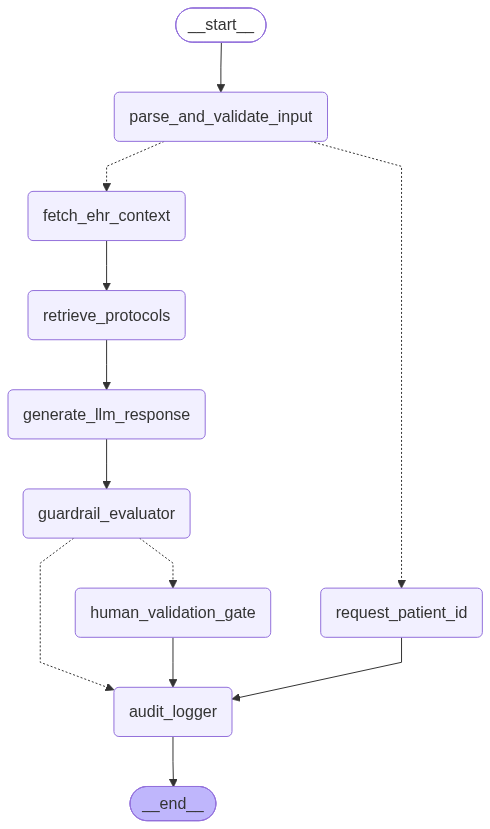

In [ ]:
from langgraph.graph import StateGraph, END
from IPython.display import Image, display

# Define the LangGraph workflow
workflow = StateGraph(GraphState)

# Add nodes to the graph
workflow.add_node("parse_and_validate_input", parse_and_validate_input)
workflow.add_node("request_patient_id", request_patient_id)
workflow.add_node("fetch_ehr_context", fetch_ehr_context)
workflow.add_node("retrieve_protocols", retrieve_protocols)
workflow.add_node("generate_llm_response", generate_llm_response)
workflow.add_node("guardrail_evaluator", guardrail_evaluator)
workflow.add_node("human_validation_gate", human_validation_gate)
workflow.add_node("audit_logger", audit_logger)

# Set the entry point of the graph
workflow.set_entry_point("parse_and_validate_input")

# Define conditional edge from parse_and_validate_input
def route_input(state: GraphState):
    if state["missing_patient_id"]:
        return "request_patient_id"
    else:
        return "fetch_ehr_context"

workflow.add_conditional_edges(
    "parse_and_validate_input", # Source node
    route_input,                # Conditional function
    {
        "request_patient_id": "request_patient_id",
        "fetch_ehr_context": "fetch_ehr_context"
    }
)

# Add direct edges
workflow.add_edge("request_patient_id", "audit_logger") # After requesting patient ID, log and end
workflow.add_edge("fetch_ehr_context", "retrieve_protocols")
workflow.add_edge("retrieve_protocols", "generate_llm_response")
workflow.add_edge("generate_llm_response", "guardrail_evaluator")

# Define conditional edge from guardrail_evaluator
def route_guardrail(state: GraphState):
    if state["requires_human_approval"]:
        return "human_validation_gate"
    else:
        return "audit_logger"

workflow.add_conditional_edges(
    "guardrail_evaluator", # Source node
    route_guardrail,       # Conditional function
    {
        "human_validation_gate": "human_validation_gate",
        "audit_logger": "audit_logger"
    }
)

workflow.add_edge("human_validation_gate", "audit_logger") # After human validation, log and end

# Finally, define the END point for audit_logger
workflow.add_edge("audit_logger", END)

# Compile the graph
app = workflow.compile()

print("LangGraph nodes and edges defined, and graph compiled.")

# Draw the graph
print("\n--- Visualizing the LangGraph ---")
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
print("\n--- Running Example 1: Query with Patient ID ---")
# Example 1: User query including a patient ID
initial_state_1 = {
    "user_query": "What is the recommended treatment for P001's diabetes?",
    "patient_id": None, # The parse_and_validate_input node will extract it
    "missing_patient_id": False,
    "patient_context": {},
    "retrieved_docs": [],
    "llm_output": "",
    "requires_human_approval": False,
    "audit_payload": {}
}

# Invoke the graph
output_state_1 = app.invoke(initial_state_1)
print("\nExample 1 Final Output (LLM Response):\n", output_state_1["llm_output"])
print("\nExample 1 Audit Payload (last entry):\n", output_state_1["audit_payload"])

print("\n--- Running Example 2: Query without Patient ID ---")
# Example 2: User query without a patient ID, expecting the system to ask for it
initial_state_2 = {
    "user_query": "What is the recommended protocol for managing anxiety?",
    "patient_id": None,
    "missing_patient_id": False,
    "patient_context": {},
    "retrieved_docs": [],
    "llm_output": "",
    "requires_human_approval": False,
    "audit_payload": {}
}

# Invoke the graph
output_state_2 = app.invoke(initial_state_2)
print("\nExample 2 Final Output (LLM Response):\n", output_state_2["llm_output"])
print("\nExample 2 Audit Payload (last entry):\n", output_state_2["audit_payload"])


print("\n--- Running Example 3: Query triggering Guardrail ---")
# Example 3: User query that might trigger guardrail (e.g., asking for a prescription)
initial_state_3 = {
    "user_query": "P003 has coronary artery disease. Should I prescribe them a new medication?",
    "patient_id": None,
    "missing_patient_id": False,
    "patient_context": {},
    "retrieved_docs": [],
    "llm_output": "",
    "requires_human_approval": False,
    "audit_payload": {}
}

# Invoke the graph
output_state_3 = app.invoke(initial_state_3)
print("\nExample 3 Final Output (LLM Response):\n", output_state_3["llm_output"])
print("\nExample 3 Audit Payload (last entry):\n", output_state_3["audit_payload"])



--- Running Example 1: Query with Patient ID ---
Patient ID 'P001' extracted from query.
--- Parsing and Validating Input ---
--- Fetched EHR Context for Patient P001 ---
--- Retrieving Protocols for Query: 'What is the recommended treatment for P001's diabetes?' ---
--- Generating LLM Response for: 'What is the recommended treatment for P001's diabetes?' ---


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer LlamaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


LLM Generated Response (first 100 chars): What are the symptoms of P001's diabetes?
The Human Phenotype Ontology provides the following list o...
--- Evaluating Guardrails ---
No sensitive content detected; human approval NOT required.
--- Logging Audit Trail ---
Audit trail successfully logged to: execution_log/audit_log_20260816_200735_787281.txt

Example 1 Final Output (LLM Response):
 What are the symptoms of P001's diabetes?
The Human Phenotype Ontology provides the following list of signs and symptoms for Diabetes mellitus. If the information is available, the table below includes how often the symptom is seen in people with this condition. You can use the MedlinePlus Medical Dictionary to look up the definitions for these medical terms. Signs and Symptoms Approximate number of patients (when available) Autosomal dominant inheritance - Diabetes mellitus - Hypertension - The Human Phenotype Ontology (HPO) has collected information on how often a sign or symptom occurs in a conditi

[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- Generating LLM Response for: 'P003 has coronary artery disease. Should I prescribe them a new medication?' ---
LLM Generated Response (first 100 chars): Yes. If your patient is taking aspirin for heart health, there is no need to add another antiplatele...
--- Evaluating Guardrails ---
No sensitive content detected; human approval NOT required.
--- Logging Audit Trail ---
Audit trail successfully logged to: execution_log/audit_log_20260816_200800_448166.txt

Example 3 Final Output (LLM Response):
 Yes. If your patient is taking aspirin for heart health, there is no need to add another antiplatelet agent to the regimen. There are two antiplatelet agents currently available: aspirin and clopidogrel. Aspirin works by preventing platelets from sticking together and forming blood clots. Clopidogrel is a newer medication that is also used to prevent blood clots. It is often used in combination with aspirin. Research suggests that the combination of aspirin and clopidogrel is more effecti